# Section 4: Benchmarks (Approximation Property)
Benchmarking the DUT's approximation property via a standard suite of reservoir
computing tasks: NARMA-10, Mackey-Glass, Lorenz'63, Sunspot Numbers, and XOR.
All benchmarks use a single scalar input (N_u=1) and are compatible with hardware
DUTs having as few as 1 input and 1-3 output electrodes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json, os, urllib.request
from pathlib import Path

from prc_toolkit.config import DT, RESULTS_DIR, SEED
from prc_toolkit.dut.factory import make_dut, prepare_input
from prc_toolkit.dut.ag2s_nwn import RECOMMENDED_PARAMS   # for switching to Ag2S-NWN
from prc_toolkit.analysis.readout import train_readout_ridge, predict_readout, nrmse

In [2]:
# ── Notebook 4: Benchmarks ──────────────────────────────
# Loads DUT configuration from results/section1_results.json (for V_SAFE and
# DUT_PARAMS) and runs a standard suite of RC benchmark tasks.

# ── DUT selection: "liesn" (default), "ag2s_nwn", or "hardware"
# (match your choice in notebooks 02 and 03) ────────────────────────────
DUT_MODEL = "liesn"
# DUT_MODEL = "ag2s_nwn"
# DUT_MODEL = "hardware"

# True whenever DUT_MODEL == "hardware".
HARDWARE_MODE = (DUT_MODEL == "hardware")

# Pre-recorded output CSVs are loaded from here when DUT_MODEL == "hardware".
# Defaults to the committed demo dataset so hardware mode works without real
# hardware attached; point this at data/hardware/outputs once you've recorded
# real data via 00_hardware_signals.ipynb.
HARDWARE_DATA_PATH = "data/demo/hardware_outputs"

# Set True (with DUT_MODEL="liesn") to regenerate data/demo/hardware_outputs/,
# then set back to False.
SAVE_DEMO_HARDWARE_DATA = False

# ── Training / test split (synthetic tasks) ──────────────
# Fixed step counts are used for generated sequences, consistent with RC
# literature convention. Percentage splits are not used for synthetic data
# since series length is unlimited.
N_WASHOUT = 200    # steps discarded at start (reservoir settles)
N_TRAIN   = 5000   # steps used to fit readout weights
N_TEST    = 1000   # steps used to evaluate NRMSE

# ── Training / test split (real data: sunspot) ────────────
# Percentage split used since dataset length is fixed.
TRAIN_FRAC = 0.70  # 70% train, 30% test (after washout)
SUNSPOT_WASHOUT = 50  # steps discarded before split

# ── XOR lag ────────────────────────────────────────────
# d=2 is the default. d=1 or d=3 are also reasonable choices.
XOR_LAG = 2

# ── Mackey-Glass parameters ───────────────────────────
MG_BETA  = 0.2
MG_GAMMA = 0.1
MG_N     = 10
MG_TAU   = 17
MG_SUBSAMPLE = 10   # integrate at dt=0.1, subsample every 10 steps
MG_X0    = 0.5
MG_H     = 1        # prediction horizon (steps ahead)

# ── Lorenz parameters ──────────────────────────────────
LZ_SIGMA = 10.0
LZ_RHO   = 28.0
LZ_BETA  = 8.0 / 3.0
LZ_DT    = 0.01     # Euler integration step
LZ_X0    = (1.0, 1.0, 1.0)
# No subsampling for Lorenz -- every Euler step is used directly.

# ── NARMA-10 parameters ────────────────────────────────
NARMA_ORDER  = 10
NARMA_ALPHA  = 0.3
NARMA_BETA   = 0.05
NARMA_GAMMA  = 1.5
NARMA_DELTA  = 0.1

# Load DUT params from Section 1 results.
# For Ag2S-NWN, set DUT_PARAMS = RECOMMENDED_PARAMS (from prc_toolkit.dut.ag2s_nwn) instead.
with open(os.path.join(RESULTS_DIR, "section1_results.json")) as f:
    s1 = json.load(f)
V_SAFE  = s1["V_SAFE"]
DUT_PARAMS = s1["DUT_params"]
# DUT_PARAMS = RECOMMENDED_PARAMS  # Uncomment to switch to Ag2S-NWN

In [3]:
assert DUT_MODEL in ("liesn", "ag2s_nwn", "hardware"), (
    f"DUT_MODEL '{DUT_MODEL}' is not supported in this notebook. "
    f"Supported values: 'liesn', 'ag2s_nwn', 'hardware'."
)

# ── Instantiate DUT ─────────────────────────────────────
dut = make_dut(DUT_MODEL, DUT_PARAMS)

In [4]:
# ── Hardware I/O helpers ─────────────────────────────────
# Plain stdlib csv module, not pandas -- this toolkit has no pandas
# dependency (see the sunspot loader below for precedent).
import csv
from pathlib import Path

def load_hardware_output(filename: str) -> np.ndarray:
    """
    Load a pre-recorded hardware output CSV from HARDWARE_DATA_PATH.

    Expected format:
      - Header row with column names h0, h1, h2, ... (one per output electrode)
      - One row per timestep
      - Values are floating-point voltage readings

    Returns H: array, shape (T, N_h).

    If the file is not found, raises FileNotFoundError with a helpful message
    directing the operator to 00_hardware_signals.ipynb for recording instructions.
    """
    path = Path(HARDWARE_DATA_PATH) / filename
    if not path.exists():
        raise FileNotFoundError(
            f"Hardware output file not found: {path}\n"
            f"Run 00_hardware_signals.ipynb and follow the recording instructions "
            f"to generate this file before running this notebook."
        )
    with open(path, newline="") as f:
        reader = csv.reader(f)
        next(reader)  # header row (h0, h1, ...)
        rows = [[float(v) for v in row] for row in reader]
    return np.array(rows, dtype=float)


DEMO_DATA_PATH = Path("data/demo/hardware_outputs")

def save_hardware_demo(filename: str, H: np.ndarray):
    """
    Save H into the committed demo dataset (data/demo/hardware_outputs/) so
    that DUT_MODEL="hardware" works out of the box without real hardware.
    No-op unless SAVE_DEMO_HARDWARE_DATA = False. Regenerate the demo dataset
    by re-running this notebook with DUT_MODEL="liesn" and
    SAVE_DEMO_HARDWARE_DATA=True.
    """
    if not SAVE_DEMO_HARDWARE_DATA:
        return
    DEMO_DATA_PATH.mkdir(parents=True, exist_ok=True)
    header = [f"h{i}" for i in range(H.shape[1])]
    with open(DEMO_DATA_PATH / filename, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(header)
        writer.writerows(H.tolist())


## Washout helper

Shared by all benchmarks below: drives the DUT through the first `n_washout`
steps of an input sequence without recording, leaving it in a settled state.

In [5]:
def washout(dut, u_seq, n_washout):
    """
    Drive dut with the first n_washout steps of u_seq (without recording).
    Leaves dut in a settled state ready for the benchmark run.
    u_seq: shape (T, 1).
    """
    for t in range(n_washout):
        dut.step(u_seq[t])

## 4.1 NARMA-10

NARMA-10 (Atiya & Parlos) is a tenth-order nonlinear autoregressive moving
average system. It tests both memory (requires 10 past states) and nonlinear
processing (product terms). The task is imitation of known dynamics: given
input u(t), reproduce x_narma(t+1). Performance is evaluated with NRMSE.

```
x_narma(t+1) = α_narma · x_narma(t)
             + β_narma · x_narma(t) · Σᵢ₌₀^{N-1} x_narma(t-i)
             + γ_narma · u(t-N+1) · u(t)
             + δ_narma
```

with α_narma=0.3, β_narma=0.05, γ_narma=1.5, δ_narma=0.1, N=10.
Input u(t) is i.i.d. uniform on [0, 0.5].

Note that the first N=10 steps are discarded as initial transient before training.

NARMA-10 NRMSE: 0.6560


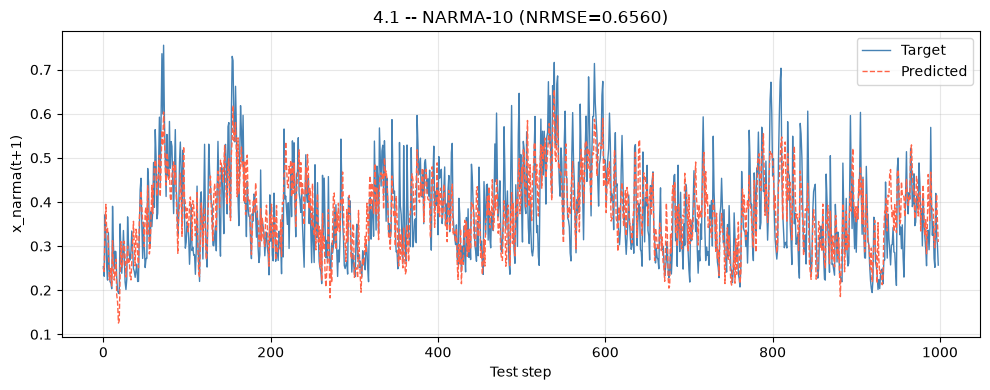

In [6]:
rng = np.random.default_rng(SEED)
T_total = N_WASHOUT + N_TRAIN + N_TEST + NARMA_ORDER

# Generate NARMA-10 input and target
u_narma = rng.uniform(0, 0.5, T_total)
x_narma = np.zeros(T_total)
for t in range(NARMA_ORDER, T_total - 1):
    x_narma[t+1] = (
        NARMA_ALPHA * x_narma[t]
        + NARMA_BETA * x_narma[t] * np.sum(x_narma[t-NARMA_ORDER+1:t+1])
        + NARMA_GAMMA * u_narma[t-NARMA_ORDER+1] * u_narma[t]
        + NARMA_DELTA
    )

u_seq = u_narma.reshape(-1, 1)  # already non-negative (U[0, 0.5]); no prepare_input needed

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_narma = load_hardware_output("section4_narma_run.csv")
else:
    dut.reset()
    washout(dut, u_seq, N_WASHOUT + NARMA_ORDER)
    H_narma = np.array([dut.step(u_seq[t]) for t in
                        range(N_WASHOUT + NARMA_ORDER, T_total - 1)])
    save_hardware_demo("section4_narma_run.csv", H_narma)
Z_narma = x_narma[N_WASHOUT + NARMA_ORDER + 1:].reshape(-1, 1)

# Train / test split
H_train, H_test = H_narma[:N_TRAIN], H_narma[N_TRAIN:]
Z_train, Z_test = Z_narma[:N_TRAIN], Z_narma[N_TRAIN:]

W_narma = train_readout_ridge(H_train, Z_train)
pred_narma = predict_readout(H_test, W_narma)
nrmse_narma = nrmse(Z_test.ravel(), pred_narma.ravel())

print(f"NARMA-10 NRMSE: {nrmse_narma:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(Z_test.ravel(), color='steelblue', lw=1, label='Target')
ax.plot(pred_narma.ravel(), color='tomato', lw=1, ls='--', label='Predicted')
ax.set_xlabel("Test step")
ax.set_ylabel("x_narma(t+1)")
ax.set_title(f"4.1 -- NARMA-10 (NRMSE={nrmse_narma:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.2 Mackey-Glass System

The Mackey-Glass system models circulating blood cell concentration and
produces a chaotic scalar time series for τ=17. The task is one-step-ahead
prediction of known chaotic dynamics. A low NRMSE here indicates strong
memory and nonlinear processing capability.

```
x(t + Δt) = x(t) + Δt · ( β · x(t-τ) / (1 + x^n(t-τ)) − γ · x(t) )
```

Integrated at Δt=0.1, subsampled every 10 steps to produce the integer-indexed
series. Standard parameters: β=0.2, γ=0.1, n=10, τ=17, x(t)=0.5 for t<0.

The series stays strictly positive (typically in [0.4, 1.4]) for these
parameters, so it is driven directly into the DUT without bias_positive().

Mackey-Glass NRMSE (h=1): 0.1445


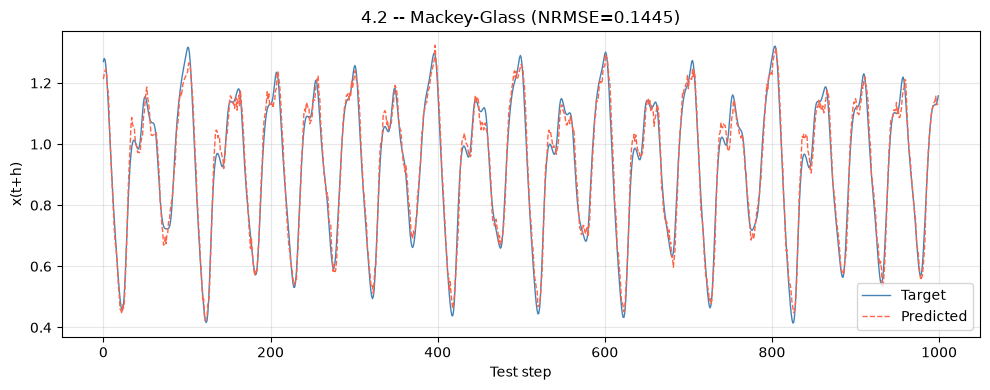

In [7]:
# Generate Mackey-Glass series
dt_mg   = 0.1
tau_steps = int(MG_TAU / dt_mg)   # delay in fine-grid steps
T_fine  = (N_WASHOUT + N_TRAIN + N_TEST + MG_H) * MG_SUBSAMPLE + tau_steps

mg = np.full(T_fine, MG_X0)
for t in range(tau_steps, T_fine - 1):
    mg[t+1] = mg[t] + dt_mg * (
        MG_BETA * mg[t - tau_steps] / (1 + mg[t - tau_steps] ** MG_N)
        - MG_GAMMA * mg[t]
    )
mg_series = mg[tau_steps::MG_SUBSAMPLE]   # subsample to integer-indexed series
assert len(mg_series) == N_WASHOUT + N_TRAIN + N_TEST + MG_H, (
    f"Expected {N_WASHOUT + N_TRAIN + N_TEST + MG_H} subsampled points, got {len(mg_series)} "
    f"-- check tau_steps/T_fine indexing."
)

u_mg = mg_series[:-MG_H].reshape(-1, 1)
z_mg = mg_series[MG_H:].reshape(-1, 1)

u_seq_mg = u_mg  # already positive; no prepare_input needed

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_mg = load_hardware_output("section4_mackeyglass_run.csv")
else:
    dut.reset()
    washout(dut, u_seq_mg, N_WASHOUT)
    H_mg = np.array([dut.step(u_seq_mg[t])
                     for t in range(N_WASHOUT, len(u_seq_mg))])
    save_hardware_demo("section4_mackeyglass_run.csv", H_mg)
Z_mg = z_mg[N_WASHOUT:]

H_train, H_test = H_mg[:N_TRAIN], H_mg[N_TRAIN:]
Z_train, Z_test = Z_mg[:N_TRAIN], Z_mg[N_TRAIN:]

W_mg = train_readout_ridge(H_train, Z_train)
pred_mg = predict_readout(H_test, W_mg)
nrmse_mg = nrmse(Z_test.ravel(), pred_mg.ravel())

print(f"Mackey-Glass NRMSE (h={MG_H}): {nrmse_mg:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(Z_test.ravel(), color='steelblue', lw=1, label='Target')
ax.plot(pred_mg.ravel(), color='tomato', lw=1, ls='--', label='Predicted')
ax.set_xlabel("Test step")
ax.set_ylabel("x(t+h)")
ax.set_title(f"4.2 -- Mackey-Glass (NRMSE={nrmse_mg:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.3 Lorenz'63 Attractor

The Lorenz'63 system is a set of three coupled ODEs producing chaotic
dynamics for standard parameters. The task is simultaneous one-step-ahead
prediction of all three state variables, given only x(t) as the scalar
input. The reservoir must reconstruct the full attractor geometry from a
single observable -- a demanding test of both memory and nonlinear capacity.
NRMSE is computed independently for each output dimension and reported as
the mean.

Euler discretization, Δt=0.01, no subsampling:

```
x(t+Δt) = x(t) + Δt · σ · (y(t) − x(t))
y(t+Δt) = y(t) + Δt · (x(t) · (ρ − z(t)) − y(t))
z(t+Δt) = z(t) + Δt · (x(t) · y(t) − β · z(t))
```

Here N_y=3 -- the readout produces a 3-dimensional output, one per Lorenz
variable. This is within the hardware constraint of ≤4 output electrodes.

Unlike the other benchmarks, x(t) swings roughly ±20 on this attractor, so
it is wrapped with `prepare_input()` (non-negative substrates only) using
the actual realized amplitude of the generated series.

Lorenz NRMSE (mean over x,y,z): 0.5430


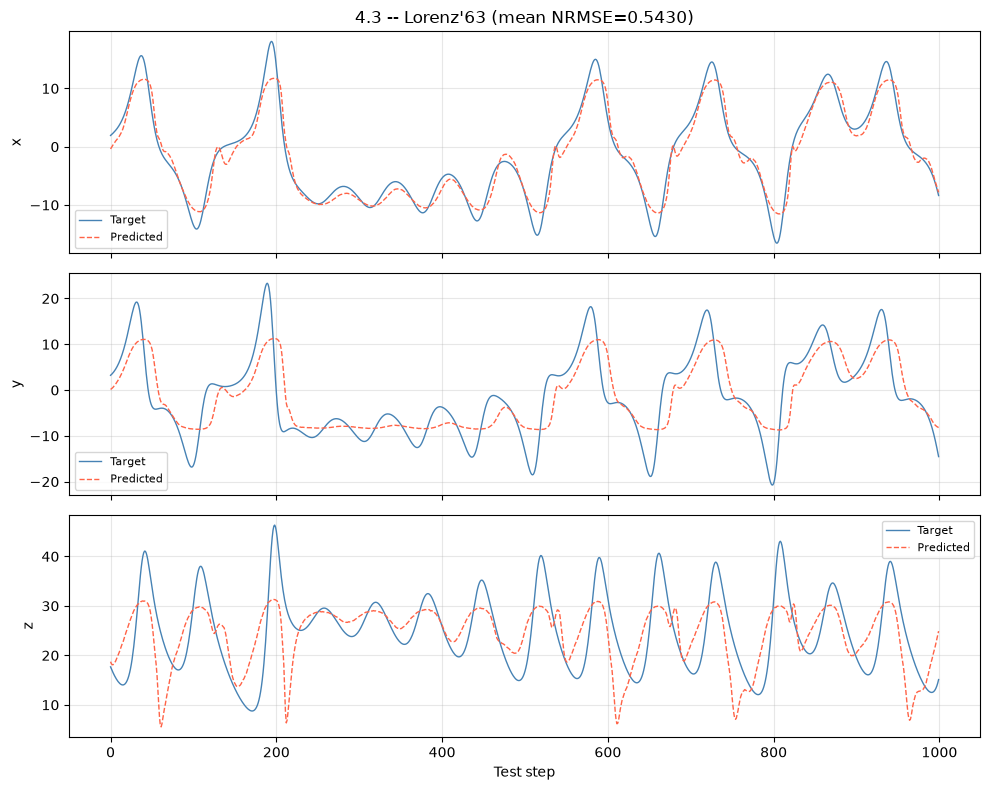

In [8]:
# Generate Lorenz series via forward Euler
T_lz = N_WASHOUT + N_TRAIN + N_TEST + 1
xyz  = np.zeros((T_lz, 3))
xyz[0] = LZ_X0
for t in range(T_lz - 1):
    x, y, z = xyz[t]
    xyz[t+1, 0] = x + LZ_DT * LZ_SIGMA * (y - x)
    xyz[t+1, 1] = y + LZ_DT * (x * (LZ_RHO - z) - y)
    xyz[t+1, 2] = z + LZ_DT * (x * y - LZ_BETA * z)

u_lz  = xyz[:-1, 0:1]          # x(t) as scalar input, shape (T-1, 1)
z_lz  = xyz[1:,  :]            # [x,y,z](t+1) as targets, shape (T-1, 3)

# x(t) is bipolar (typically +/-20 on this attractor) -- unlike every other
# benchmark's input here, it needs prepare_input(). Its amplitude is a
# property of the attractor's realized trajectory, not a fixed design
# parameter like V_SAFE, so use the actual max magnitude reached.
lz_amplitude = float(np.max(np.abs(u_lz)))
u_seq_lz = prepare_input(u_lz, lz_amplitude, DUT_MODEL)

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_lz = load_hardware_output("section4_lorenz_run.csv")
else:
    dut.reset()
    washout(dut, u_seq_lz, N_WASHOUT)
    H_lz = np.array([dut.step(u_seq_lz[t])
                     for t in range(N_WASHOUT, len(u_seq_lz))])
    save_hardware_demo("section4_lorenz_run.csv", H_lz)
Z_lz = z_lz[N_WASHOUT:]

H_train, H_test = H_lz[:N_TRAIN], H_lz[N_TRAIN:]
Z_train, Z_test = Z_lz[:N_TRAIN], Z_lz[N_TRAIN:]

W_lz   = train_readout_ridge(H_train, Z_train)
pred_lz = predict_readout(H_test, W_lz)
nrmse_lz = float(np.mean([nrmse(Z_test[:, k], pred_lz[:, k]) for k in range(3)]))

print(f"Lorenz NRMSE (mean over x,y,z): {nrmse_lz:.4f}")

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
labels = ['x', 'y', 'z']
for k in range(3):
    axes[k].plot(Z_test[:, k], color='steelblue', lw=1, label='Target')
    axes[k].plot(pred_lz[:, k], color='tomato', lw=1, ls='--', label='Predicted')
    axes[k].set_ylabel(labels[k])
    axes[k].legend(fontsize=8)
    axes[k].grid(True, alpha=0.3)
axes[-1].set_xlabel("Test step")
axes[0].set_title(f"4.3 -- Lorenz'63 (mean NRMSE={nrmse_lz:.4f})")
plt.tight_layout()
plt.show()

## 4.4 Sunspot Numbers

Sunspot numbers are a real-world dataset of unknown underlying dynamics,
recorded consistently since 1749. The task is one-step-ahead prediction of
the monthly mean sunspot number -- a standard RC benchmark for prediction of
unknown dynamics. Unlike the synthetic tasks, the dataset is finite; a 70/30
train/test split is used.

Comparison between implementations is sensitive to dataset version and
preprocessing. This notebook uses the WDC-SILSO Royal Observatory of Belgium
monthly mean total sunspot number series (Version 2.0).

**Note on the download link:** the series is nominally published at
`https://www.sidc.be/products/sn/SN_m_tot_V2.0.txt` (a fixed-width text
file), but that host was not reachable from this build environment. The
same data is also available as CSV from
`https://www.sidc.be/SILSO/datafiles` -> "CSV" next to "Monthly mean total
sunspot number" -> `https://www.sidc.be/SILSO/INFO/snmtotcsv.php` (this page
may require manually clicking through rather than a direct download). The
semicolon-delimited CSV from that second link was used to build the bundled
`data/sunspot_monthly.csv`.

In [9]:
SUNSPOT_PATH = Path("data/sunspot_monthly.csv")

# ── Bundled dataset (default) ──────────────────────────
# data/sunspot_monthly.csv is committed alongside this notebook. It was
# parsed from the WDC-SILSO monthly mean sunspot number series (see the
# note on the download link above) using the stdlib csv module -- no
# pandas dependency needed for a plain two-column CSV.
import csv

year_months, ss_values = [], []
with open(SUNSPOT_PATH, newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        year_months.append(float(row["year_month"]))
        sn = float(row["sunspot_number"])
        # -1 is this dataset's missing-data sentinel; the bundled CSV has
        # already had these rows dropped, but re-check in case a refreshed
        # download reintroduces them.
        if sn == -1:
            continue
        ss_values.append(sn)
ss_values = np.array(ss_values)

# ── Runtime download (commented out) ───────────────────
# Uncomment to fetch a fresh WDC-SILSO snapshot instead of the bundled one.
# Requires network access to sidc.be, which may be blocked by egress policy
# in some environments (it was in the one this notebook was built in).
#
# url = "https://www.sidc.be/products/sn/SN_m_tot_V2.0.txt"
# raw = urllib.request.urlopen(url).read().decode()
# rows = []
# for line in raw.strip().splitlines():
#     cols = line.split()
#     val = float(cols[3])
#     if val >= 0:   # -1 indicates missing data in this dataset
#         rows.append({"year_month": float(cols[2]), "sunspot_number": val})
# ss_values = np.array([r["sunspot_number"] for r in rows])

print(f"Loaded {len(ss_values)} monthly sunspot observations "
      f"({year_months[0]:.1f} to {year_months[-1]:.1f}).")

Loaded 3331 monthly sunspot observations (1749.0 to 2026.5).


Sunspot NRMSE: 0.3374


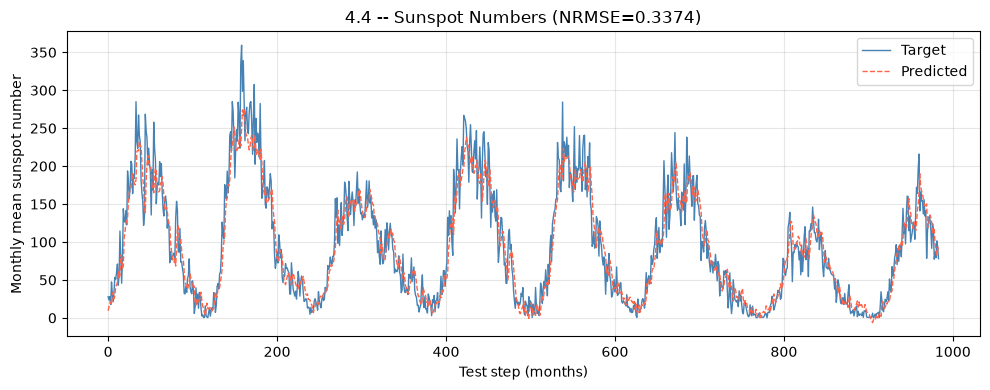

In [10]:
# Normalize to [0, 1] for stable reservoir driving
ss_min, ss_max = ss_values.min(), ss_values.max()
ss_norm = (ss_values - ss_min) / (ss_max - ss_min)

u_ss = ss_norm[:-1].reshape(-1, 1)
z_ss = ss_norm[1:].reshape(-1, 1)

u_seq_ss = u_ss  # already non-negative (normalized to [0,1]); no prepare_input needed

# 70/30 split after washout
n_total  = len(u_ss) - SUNSPOT_WASHOUT
n_train  = int(n_total * TRAIN_FRAC)
n_test   = n_total - n_train

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_ss = load_hardware_output("section4_sunspot_run.csv")
else:
    dut.reset()
    washout(dut, u_seq_ss, SUNSPOT_WASHOUT)
    H_ss = np.array([dut.step(u_seq_ss[t])
                     for t in range(SUNSPOT_WASHOUT, len(u_seq_ss))])
    save_hardware_demo("section4_sunspot_run.csv", H_ss)
Z_ss = z_ss[SUNSPOT_WASHOUT:]

H_train, H_test = H_ss[:n_train], H_ss[n_train:]
Z_train, Z_test = Z_ss[:n_train], Z_ss[n_train:]

W_ss   = train_readout_ridge(H_train, Z_train)
pred_ss = predict_readout(H_test, W_ss)
nrmse_ss = nrmse(Z_test.ravel(), pred_ss.ravel())

print(f"Sunspot NRMSE: {nrmse_ss:.4f}")

# Denormalize for the plot so the y-axis shows actual sunspot numbers.
target_actual = Z_test.ravel() * (ss_max - ss_min) + ss_min
pred_actual   = pred_ss.ravel() * (ss_max - ss_min) + ss_min

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(target_actual, color='steelblue', lw=1, label='Target')
ax.plot(pred_actual, color='tomato', lw=1, ls='--', label='Predicted')
ax.set_xlabel("Test step (months)")
ax.set_ylabel("Monthly mean sunspot number")
ax.set_title(f"4.4 -- Sunspot Numbers (NRMSE={nrmse_ss:.4f})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.5 XOR Task

XOR is a binary computation benchmark. Given a binary input stream u(t) ∈
{0,1}, the target is the XOR of two values separated by lag d:

```
y_target(t) = u(t) ⊕ u(t − d)
```

This simultaneously tests nonlinear processing (XOR is not linearly
separable) and memory (lag d requires retention of past inputs). The readout
output is thresholded at 0.5 to produce a binary prediction; performance is
reported as classification accuracy. Note: d=2 is used here (`XOR_LAG` in
the configuration cell); d=1 or d=3 are also reasonable choices.

Targets are {0,1} and the 0.5 threshold follows from this convention. The
input stream is already non-negative, so it is driven directly without
bias_positive().

**What good XOR performance looks like:** In the ideal case the predicted
signal (dashed) exactly overlaps the target (solid) in the test plot below —
a binary square wave at the XOR lag. Accuracy near 1.0 indicates the
reservoir successfully computed the nonlinear combination u(t) XOR u(t−d).
Accuracy near 0.5 (chance) means the readout cannot separate the two classes,
typically because the reservoir lacks sufficient nonlinear memory at delay d.
XOR performance is sensitive to dynamical regime: critical and mildly chaotic
reservoirs generally outperform ordered ones on this task, since XOR requires
both memory (to retain u(t−d)) and nonlinearity (to compute the XOR function).
With only N_h output electrodes driving a linear classifier, performance also
degrades when N_h is small — increasing N_h or the spectral radius may
substantially improve accuracy.

XOR Accuracy (d=2): 0.6060


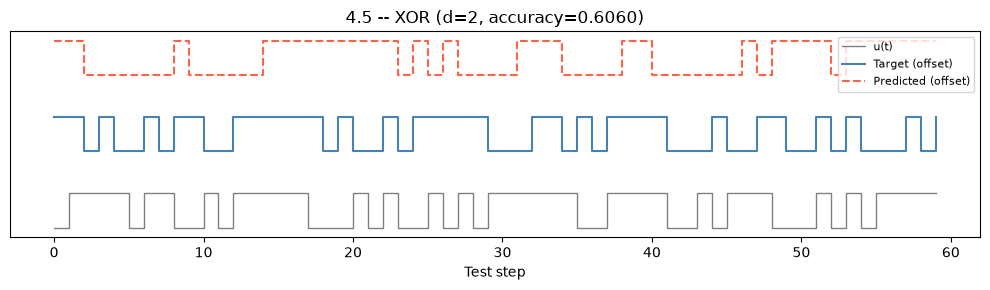

In [11]:
rng_xor = np.random.default_rng(SEED + 1)   # separate seed from NARMA
T_xor   = N_WASHOUT + N_TRAIN + N_TEST + XOR_LAG

u_xor_raw = rng_xor.integers(0, 2, T_xor).astype(float)
y_xor_raw = np.zeros(T_xor)
for t in range(XOR_LAG, T_xor):
    y_xor_raw[t] = float(int(u_xor_raw[t]) ^ int(u_xor_raw[t - XOR_LAG]))

u_seq_xor = u_xor_raw.reshape(-1, 1)  # already {0,1}; no prepare_input needed

# --- Data collection ---
if DUT_MODEL == "hardware":
    H_xor = load_hardware_output("section4_xor_run.csv")
else:
    dut.reset()
    washout(dut, u_seq_xor, N_WASHOUT + XOR_LAG)
    H_xor = np.array([dut.step(u_seq_xor[t]) for t in
                      range(N_WASHOUT + XOR_LAG, T_xor)])
    save_hardware_demo("section4_xor_run.csv", H_xor)
Z_xor = y_xor_raw[N_WASHOUT + XOR_LAG:].reshape(-1, 1)

H_train, H_test = H_xor[:N_TRAIN], H_xor[N_TRAIN:]
Z_train, Z_test = Z_xor[:N_TRAIN], Z_xor[N_TRAIN:]

W_xor   = train_readout_ridge(H_train, Z_train)
pred_xor_raw = predict_readout(H_test, W_xor).ravel()
pred_xor = (pred_xor_raw >= 0.5).astype(float)
accuracy_xor = float(np.mean(pred_xor == Z_test.ravel()))

print(f"XOR Accuracy (d={XOR_LAG}): {accuracy_xor:.4f}")

fig, ax = plt.subplots(figsize=(10, 3))
n_show = 60
ax.step(range(n_show), u_seq_xor[N_WASHOUT + XOR_LAG:N_WASHOUT + XOR_LAG + n_show].ravel(),
        where='post', color='gray', lw=1, label='u(t)')
ax.step(range(n_show), Z_test[:n_show].ravel() + 2.2, where='post',
        color='steelblue', lw=1.5, label='Target (offset)')
ax.step(range(n_show), pred_xor[:n_show] + 4.4, where='post',
        color='tomato', lw=1.5, ls='--', label='Predicted (offset)')
ax.set_xlabel("Test step")
ax.set_yticks([])
ax.set_title(f"4.5 -- XOR (d={XOR_LAG}, accuracy={accuracy_xor:.4f})")
ax.legend(fontsize=8, loc='upper right')
plt.tight_layout()
plt.show()

## Results Summary

In [12]:
section4_results = {
    "nrmse_narma10":      float(nrmse_narma),
    "nrmse_mackey_glass": float(nrmse_mg),
    "nrmse_lorenz":       float(nrmse_lz),
    "nrmse_sunspot":      float(nrmse_ss),
    "xor_accuracy":       float(accuracy_xor),
    "xor_lag":            XOR_LAG,
    "mg_horizon":         MG_H,
    "test_params": {
        "DUT_MODEL":  DUT_MODEL,
        "N_WASHOUT":  N_WASHOUT,
        "N_TRAIN":    N_TRAIN,
        "N_TEST":     N_TEST,
        "TRAIN_FRAC": TRAIN_FRAC,
    }
}

os.makedirs(RESULTS_DIR, exist_ok=True)
with open(os.path.join(RESULTS_DIR, "section4_results.json"), "w") as f:
    json.dump(section4_results, f, indent=2)

print("Results saved to", os.path.join(RESULTS_DIR, "section4_results.json"))
print(f"  NARMA-10 NRMSE:      {nrmse_narma:.4f}")
print(f"  Mackey-Glass NRMSE:  {nrmse_mg:.4f}")
print(f"  Lorenz NRMSE:        {nrmse_lz:.4f}")
print(f"  Sunspot NRMSE:       {nrmse_ss:.4f}")
print(f"  XOR Accuracy:        {accuracy_xor:.4f}  (d={XOR_LAG})")

Results saved to results/section4_results.json
  NARMA-10 NRMSE:      0.6560
  Mackey-Glass NRMSE:  0.1445
  Lorenz NRMSE:        0.5430
  Sunspot NRMSE:       0.3374
  XOR Accuracy:        0.6060  (d=2)
